<a href="https://colab.research.google.com/github/sanchi23002/Basic_Pandas/blob/main/drone_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# CELL 0: GPU CHECK + INSTALLS
# ============================================================
import torch
print("torch version:", torch.__version__)
print("torch built with CUDA:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM: {vram_gb:.1f} GB")
else:
    raise RuntimeError("NO GPU! Go to Runtime → Change runtime type → T4 GPU")

# GPU performance flags
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nusing device:", device)

# Install
!pip install -q ultralytics>=8.2.0 optuna>=3.6.0

import ultralytics
ultralytics.checks()

import optuna
print(f"optuna version: {optuna.__version__}")
print("\n All good. Move to Cell 1.")

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 48.3/112.6 GB disk)
optuna version: 5.0.0

 All good. Move to Cell 1.


In [3]:
# ============================================================
# CELL 1: UNZIP LOCAL UPLOAD
# ============================================================
import os, time

# ──────────────────────────────────────────────
# PATHS BASED ON DIRECT COLAB UPLOAD
# ──────────────────────────────────────────────
ZIP_PATH = '/content/drone detection.v2i.yolov8.zip'
DATASET_ROOT = '/content'

assert os.path.exists(ZIP_PATH), f"❌ Not found: {ZIP_PATH}"

start = time.time()
!unzip -q -o "{ZIP_PATH}" -d /content/
print(f"✅ Unzipped in {time.time()-start:.0f}s")

for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(DATASET_ROOT, split, 'images')
    lbl_dir = os.path.join(DATASET_ROOT, split, 'labels')
    if os.path.isdir(img_dir) and os.path.isdir(lbl_dir):
        n_img = len([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        n_lbl = len([f for f in os.listdir(lbl_dir) if f.endswith('.txt')])
        print(f"  {split}: {n_img} images, {n_lbl} labels")
    else:
        print(f"  ⚠️ {split}: not found — check folder structure")

✅ Unzipped in 2s
  train: 4914 images, 4914 labels
  valid: 1396 images, 1396 labels
  test: 700 images, 700 labels


In [4]:
# ============================================================
# CELL 1: DOWNLOAD DATASET FROM ROBOFLOW
# ============================================================
!pip install -q roboflow

from roboflow import Roboflow
import os

rf = Roboflow(api_key="5NzPEfccpScqZn4QsuZK")
project = rf.workspace("dronenotdrone").project("drone-detection-pq8sj")
version = project.version(2)
dataset = version.download("yolov8", location="/content/dataset")

DATASET_ROOT = "/content/dataset"

for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(DATASET_ROOT, split, 'images')
    lbl_dir = os.path.join(DATASET_ROOT, split, 'labels')
    if os.path.isdir(img_dir) and os.path.isdir(lbl_dir):
        n_img = len([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        n_lbl = len([f for f in os.listdir(lbl_dir) if f.endswith('.txt')])
        print(f"  {split}: {n_img} images, {n_lbl} labels")
    else:
        print(f"  ⚠️ {split}: not found")

loading Roboflow workspace...
loading Roboflow project...
  train: 4914 images, 4914 labels
  valid: 1396 images, 1396 labels
  test: 700 images, 700 labels


In [5]:
# ============================================================
# CELL 2: DATA CLEANING — Find and fix broken images + labels
# ============================================================
import cv2
import numpy as np
from collections import Counter
import shutil

def clean_dataset(dataset_root, split, class_names, fix=True):
    img_dir = os.path.join(dataset_root, split, 'images')
    lbl_dir = os.path.join(dataset_root, split, 'labels')
    quarantine = os.path.join(dataset_root, f'{split}_quarantine')

    issues = {
        'corrupt_images': [],
        'missing_labels': [],
        'empty_labels': [],
        'invalid_class_id': [],
        'invalid_bbox': [],
        'orphan_labels': [],
        'zero_area_bbox': [],
    }

    img_files = {os.path.splitext(f)[0]: f for f in os.listdir(img_dir)
                 if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))}
    lbl_files = {os.path.splitext(f)[0]: f for f in os.listdir(lbl_dir)
                 if f.endswith('.txt')}

    nc = len(class_names)
    class_counts = Counter()
    total_objects = 0
    sizes = []

    for stem, img_name in img_files.items():
        img_path = os.path.join(img_dir, img_name)

        img = cv2.imread(img_path)
        if img is None:
            issues['corrupt_images'].append(img_name)
            continue
        h, w = img.shape[:2]

        if stem not in lbl_files:
            issues['missing_labels'].append(img_name)
            continue

        lbl_path = os.path.join(lbl_dir, lbl_files[stem])
        with open(lbl_path, 'r') as f:
            lines = [l.strip() for l in f if l.strip()]

        if not lines:
            issues['empty_labels'].append(lbl_files[stem])
            continue

        file_has_issue = False
        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                issues['invalid_bbox'].append((lbl_files[stem], line))
                file_has_issue = True
                continue

            try:
                cls_id = int(parts[0])
                xc, yc, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            except ValueError:
                issues['invalid_bbox'].append((lbl_files[stem], line))
                file_has_issue = True
                continue

            if cls_id < 0 or cls_id >= nc:
                issues['invalid_class_id'].append((lbl_files[stem], cls_id))
                file_has_issue = True
                continue

            if not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 < bw <= 1 and 0 < bh <= 1):
                issues['invalid_bbox'].append((lbl_files[stem], f'coords out of range: {xc},{yc},{bw},{bh}'))
                file_has_issue = True
                continue

            area = bw * bh
            if area < 1e-6:
                issues['zero_area_bbox'].append((lbl_files[stem], f'area={area:.8f}'))
                file_has_issue = True
                continue

            class_counts[cls_id] += 1
            total_objects += 1
            sizes.append(area)

    for stem in lbl_files:
        if stem not in img_files:
            issues['orphan_labels'].append(lbl_files[stem])

    print(f"\n{'='*60}")
    print(f"  DATA CLEANING REPORT: {split.upper()}")
    print(f"{'='*60}")
    print(f"  Total images scanned:  {len(img_files)}")
    print(f"  Total valid objects:   {total_objects}")
    print(f"  Class distribution:")
    for cid in sorted(class_counts.keys()):
        name = class_names[cid] if cid < len(class_names) else f'unknown_{cid}'
        pct = class_counts[cid] / total_objects * 100 if total_objects > 0 else 0
        print(f"    Class {cid} ({name}): {class_counts[cid]} ({pct:.1f}%)")

    print(f"\n  Issues found:")
    total_issues = 0
    for issue_type, items in issues.items():
        if items:
            print(f"    ⚠️  {issue_type}: {len(items)}")
            total_issues += len(items)

    if total_issues == 0:
        print(f"    ✅ No issues found — dataset is clean!")

    if fix and total_issues > 0:
        os.makedirs(quarantine, exist_ok=True)
        moved = 0
        for img_name in issues['corrupt_images']:
            src = os.path.join(img_dir, img_name)
            if os.path.exists(src):
                shutil.move(src, os.path.join(quarantine, img_name))
                moved += 1
                stem = os.path.splitext(img_name)[0]
                lbl_src = os.path.join(lbl_dir, stem + '.txt')
                if os.path.exists(lbl_src):
                    shutil.move(lbl_src, os.path.join(quarantine, stem + '.txt'))
        if moved:
            print(f"\n    🗑️  Moved {moved} corrupt images to {quarantine}")

    return issues, class_counts, np.array(sizes)

CLASS_NAMES = ['drone', 'bird']   # ← CHANGE to your real class names if different

print("🔍 Scanning and cleaning dataset...")
train_issues, train_counts, train_sizes = clean_dataset(DATASET_ROOT, 'train', CLASS_NAMES)
val_issues, val_counts, val_sizes = clean_dataset(DATASET_ROOT, 'valid', CLASS_NAMES)
test_issues, test_counts, test_sizes = clean_dataset(DATASET_ROOT, 'test', CLASS_NAMES)

🔍 Scanning and cleaning dataset...

  DATA CLEANING REPORT: TRAIN
  Total images scanned:  4914
  Total valid objects:   10537
  Class distribution:
    Class 0 (drone): 4518 (42.9%)
    Class 1 (bird): 6019 (57.1%)

  Issues found:
    ⚠️  empty_labels: 24

  DATA CLEANING REPORT: VALID
  Total images scanned:  1396
  Total valid objects:   2559
  Class distribution:
    Class 0 (drone): 1308 (51.1%)
    Class 1 (bird): 1251 (48.9%)

  Issues found:
    ⚠️  empty_labels: 9
    ⚠️  invalid_bbox: 1

  DATA CLEANING REPORT: TEST
  Total images scanned:  700
  Total valid objects:   1216
  Class distribution:
    Class 0 (drone): 669 (55.0%)
    Class 1 (bird): 547 (45.0%)

  Issues found:
    ⚠️  empty_labels: 2


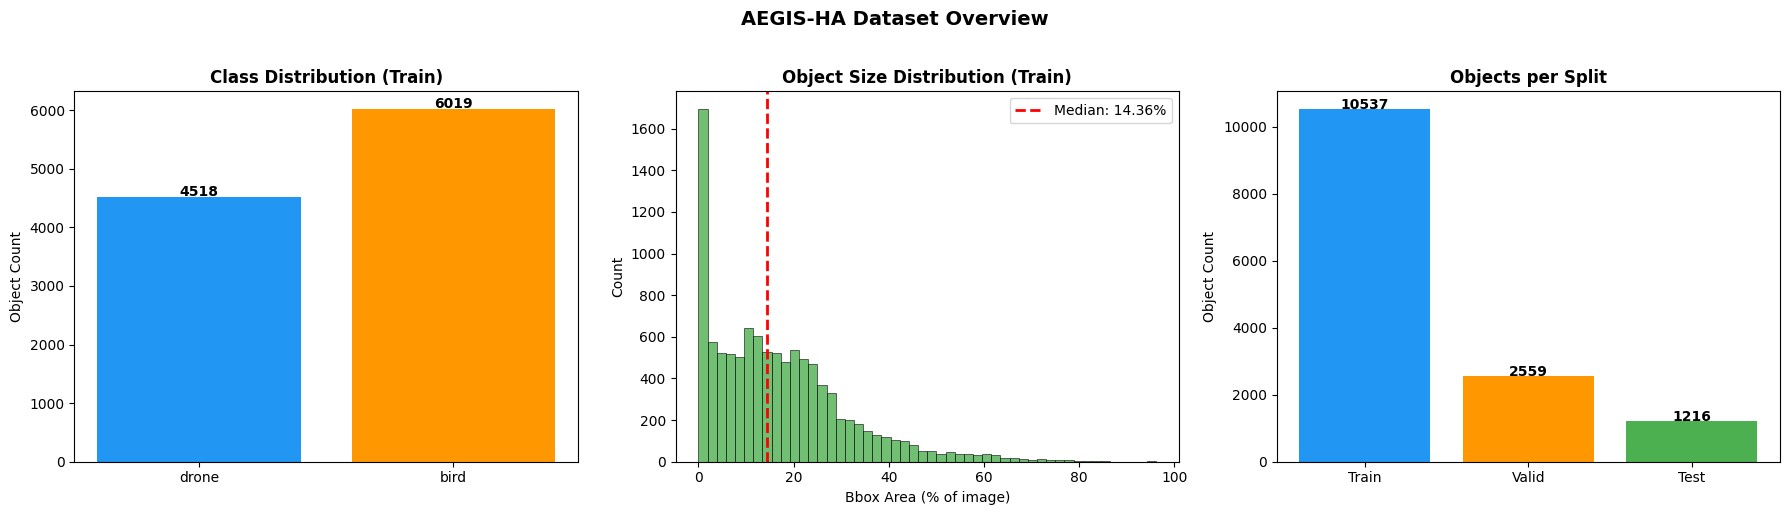


📊 16.3% of objects are SMALL (< 2% image area)
   → Objects are reasonably sized; imgsz=640 should be fine
   Class imbalance ratio: 1.3:1


In [6]:
# ============================================================
# CELL 3: VISUALIZE DATA DISTRIBUTION
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

classes = [CLASS_NAMES[i] for i in sorted(train_counts.keys())]
counts = [train_counts[i] for i in sorted(train_counts.keys())]
colors = ['#2196F3', '#FF9800']
bars = axes[0].bar(classes, counts, color=colors[:len(classes)])
axes[0].set_title('Class Distribution (Train)', fontweight='bold')
axes[0].set_ylabel('Object Count')
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
                 str(count), ha='center', fontweight='bold')

if len(train_sizes) > 0:
    axes[1].hist(train_sizes * 100, bins=50, color='#4CAF50', alpha=0.8, edgecolor='black', linewidth=0.5)
    median_size = np.median(train_sizes) * 100
    axes[1].axvline(x=median_size, color='red', linestyle='--', linewidth=2, label=f'Median: {median_size:.2f}%')
    axes[1].set_xlabel('Bbox Area (% of image)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Object Size Distribution (Train)', fontweight='bold')
    axes[1].legend()

splits = ['Train', 'Valid', 'Test']
split_sizes = [
    sum(train_counts.values()),
    sum(val_counts.values()),
    sum(test_counts.values())
]
axes[2].bar(splits, split_sizes, color=['#2196F3', '#FF9800', '#4CAF50'])
axes[2].set_title('Objects per Split', fontweight='bold')
axes[2].set_ylabel('Object Count')
for i, v in enumerate(split_sizes):
    axes[2].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('AEGIS-HA Dataset Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

if len(train_sizes) > 0:
    small_pct = (train_sizes < 0.02).sum() / len(train_sizes) * 100
    print(f"\n📊 {small_pct:.1f}% of objects are SMALL (< 2% image area)")
    if small_pct > 50:
        print("   → Optuna will search imgsz up to 800 to capture these")
    else:
        print("   → Objects are reasonably sized; imgsz=640 should be fine")

imbalance_ratio = max(counts) / (min(counts) + 1)
print(f"   Class imbalance ratio: {imbalance_ratio:.1f}:1")
if imbalance_ratio > 3:
    print("   → Significant imbalance — Optuna search includes augmentation to help")

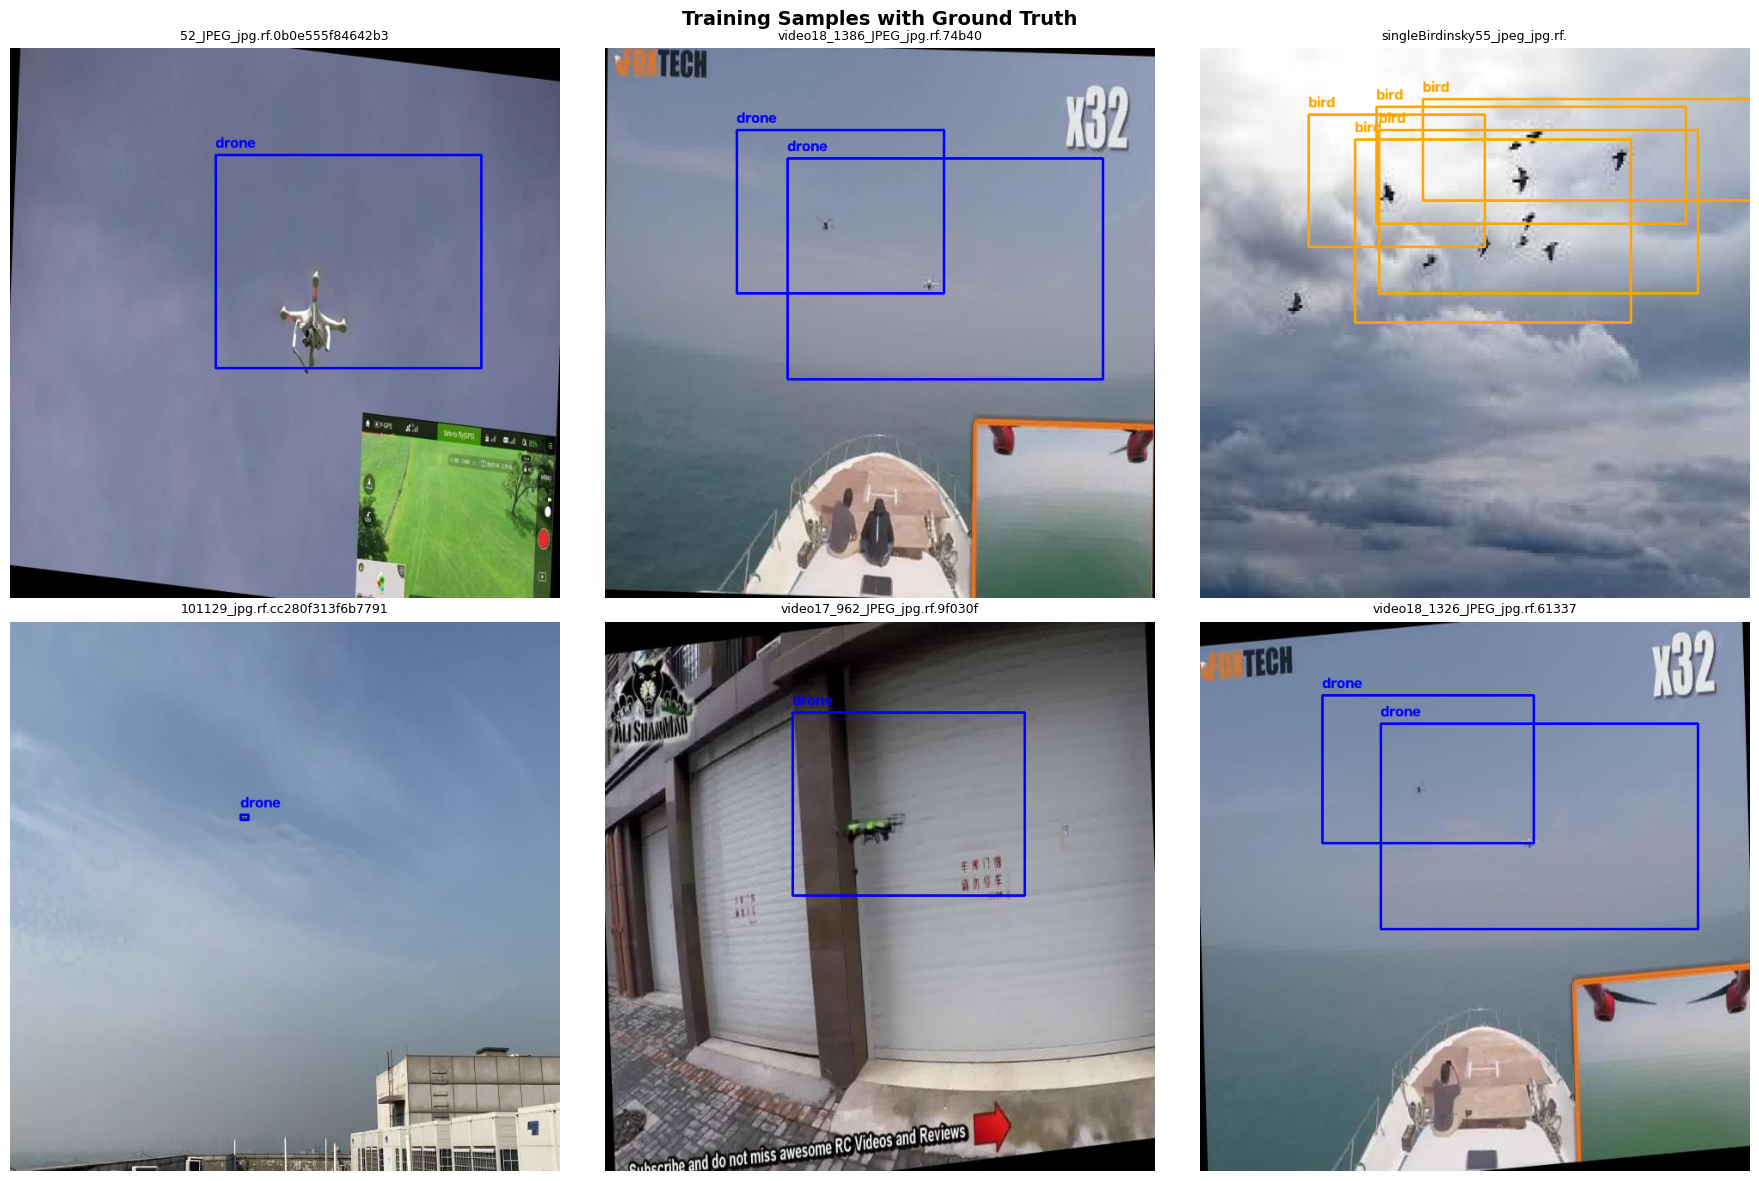

In [7]:
# ============================================================
# CELL 4: SAMPLE VISUALIZATION
# ============================================================
import cv2
import random

def visualize_yolo_sample(img_dir, lbl_dir, class_names, n=6):
    imgs = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    samples = random.sample(imgs, min(n, len(imgs)))

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    colors = [(0, 0, 255), (255, 165, 0)]

    for ax, img_name in zip(axes.flat, samples):
        img = cv2.imread(os.path.join(img_dir, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        lbl_path = os.path.join(lbl_dir, os.path.splitext(img_name)[0] + '.txt')
        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls_id = int(parts[0])
                        xc, yc, bw, bh = [float(x) for x in parts[1:5]]
                        x1, y1 = int((xc - bw/2)*w), int((yc - bh/2)*h)
                        x2, y2 = int((xc + bw/2)*w), int((yc + bh/2)*h)
                        color = colors[cls_id % len(colors)]
                        cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
                        label = class_names[cls_id] if cls_id < len(class_names) else f'cls_{cls_id}'
                        cv2.putText(img, label, (x1, y1-8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        ax.imshow(img)
        ax.set_title(img_name[:30], fontsize=9)
        ax.axis('off')

    plt.suptitle('Training Samples with Ground Truth', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_yolo_sample(
    os.path.join(DATASET_ROOT, 'train', 'images'),
    os.path.join(DATASET_ROOT, 'train', 'labels'),
    CLASS_NAMES
)

In [8]:
# ============================================================
# CELL 5: GENERATE data.yaml
# ============================================================
yaml_content = f"""# AEGIS-HA Drone Detection Dataset
path: {DATASET_ROOT}
train: train/images
val: valid/images
test: test/images

nc: {len(CLASS_NAMES)}
names: {CLASS_NAMES}
"""

yaml_path = os.path.join(DATASET_ROOT, 'data.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"✅ Saved to {yaml_path}")

✅ Saved to /content/dataset/data.yaml


In [11]:
# ============================================================
# CELL 6: DEFINE OPTUNA OBJECTIVE FUNCTION (TIGHTENED)
# ============================================================
import optuna
from ultralytics import RTDETR
import torch
import gc
import time
import shutil
import os
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.benchmark = True

OPTUNA_DIR = '/content/optuna_runs'
DRIVE_SAVE = '/content/drive/MyDrive/AEGIS_HA_Results'
os.makedirs(OPTUNA_DIR, exist_ok=True)

def objective(trial):
    trial_start = time.time()

    lr0 = trial.suggest_float("lr0", 5e-5, 5e-4, log=True)
    lrf = trial.suggest_float("lrf", 0.01, 0.05)

    epochs = trial.suggest_int("epochs", 5, 8, step=1)
    warmup_epochs = trial.suggest_int("warmup_epochs", 1, 2)

    batch = 8
    imgsz = 640

    weight_decay = trial.suggest_float("weight_decay", 5e-4, 5e-3, log=True)

    mosaic = trial.suggest_float("mosaic", 0.5, 1.0, step=0.1)
    mixup = trial.suggest_float("mixup", 0.0, 0.15, step=0.05)
    scale = trial.suggest_float("scale", 0.3, 0.6, step=0.1)

    trial_name = f'trial_{trial.number}'

    print(f"\n{'━'*60}")
    print(f"  TRIAL {trial.number} | lr0={lr0:.6f} epochs={epochs} wd={weight_decay:.6f}")
    print(f"  mosaic={mosaic:.1f} mixup={mixup:.2f} scale={scale:.1f} warmup={warmup_epochs}")
    print(f"{'━'*60}")

    try:
        model = RTDETR('rtdetr-l.pt')

        results = model.train(
            data=yaml_path,
            epochs=epochs,
            imgsz=imgsz,
            batch=batch,
            lr0=lr0,
            lrf=lrf,
            weight_decay=weight_decay,
            warmup_epochs=warmup_epochs,
            mosaic=mosaic,
            mixup=mixup,
            scale=scale,
            device=device,
            cos_lr=True,
            close_mosaic=max(1, epochs // 4),
            warmup_bias_lr=0.01,
            warmup_momentum=0.8,
            hsv_h=0.015,
            hsv_s=0.7,
            hsv_v=0.4,
            degrees=10.0,
            translate=0.15,
            fliplr=0.5,
            flipud=0.0,
            amp=True,
            workers=4,
            patience=max(2, epochs // 2),
            save=True,
            save_period=-1,
            project=OPTUNA_DIR,
            name=trial_name,
            exist_ok=True,
            verbose=False,
            plots=False,
        )

        val_results = model.val(
            data=yaml_path, split='val', imgsz=imgsz,
            batch=batch, device=device, verbose=False
        )
        map50 = float(val_results.box.map50)
        map50_95 = float(val_results.box.map)
        precision = float(val_results.box.mp)
        recall = float(val_results.box.mr)

        elapsed = (time.time() - trial_start) / 60
        print(f"\n  ✅ Trial {trial.number} done in {elapsed:.1f} min")
        print(f"     mAP@50={map50:.4f}  mAP@50-95={map50_95:.4f}"
              f"  P={precision:.4f}  R={recall:.4f}")

        trial.set_user_attr("map50_95", map50_95)
        trial.set_user_attr("precision", precision)
        trial.set_user_attr("recall", recall)
        trial.set_user_attr("train_time_min", elapsed)

    except RuntimeError as e:
        if "out of memory" in str(e).lower() or "CUDA" in str(e):
            print(f"  ❌ Trial {trial.number} OOM — pruning")
            torch.cuda.empty_cache()
            gc.collect()
            raise optuna.exceptions.TrialPruned()
        else:
            raise
    finally:
        torch.cuda.empty_cache()
        gc.collect()
        trial_dir = os.path.join(OPTUNA_DIR, trial_name)
        weights_dir = os.path.join(trial_dir, 'weights')
        if os.path.isdir(weights_dir):
            last_pt = os.path.join(weights_dir, 'last.pt')
            if os.path.exists(last_pt):
                os.remove(last_pt)

    return map50

print("✅ Objective function defined (tightened, epochs 3-10, 10 trials).")

✅ Objective function defined (tightened, epochs 3-10, 10 trials).


In [12]:
# ============================================================
# CELL 7: RUN OPTUNA SEARCH — 10 TRIALS
# ============================================================
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import joblib
import time
import shutil
import os

N_TRIALS = 3
STUDY_NAME = 'aegis_rtdetr_optuna_v2'
STUDY_DB = f'/content/{STUDY_NAME}.db'
DRIVE_SAVE = '/content/drive/MyDrive/AEGIS_HA_Results'

storage = f'sqlite:///{STUDY_DB}'

study = optuna.create_study(
    study_name=STUDY_NAME,
    direction="maximize",
    storage=storage,
    load_if_exists=True,
    sampler=TPESampler(
        seed=42,
        n_startup_trials=3,
        multivariate=True,
    ),
    pruner=MedianPruner(
        n_startup_trials=2,
        n_warmup_steps=0,
    ),
)

completed = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
remaining = max(0, N_TRIALS - completed)

if completed > 0:
    print(f"📂 Resuming study: {completed} trials already complete")
    print(f"   Current best mAP@50: {study.best_value:.4f}")
    print(f"   Running {remaining} more trials...\n")
else:
    print(f"🚀 Starting fresh Optuna search: {N_TRIALS} trials")

search_start = time.time()

if remaining > 0:
    study.optimize(
        objective,
        n_trials=remaining,
        gc_after_trial=True,
        show_progress_bar=True,
    )

total_time = (time.time() - search_start) / 3600

print(f"\n{'═'*60}")
print(f"  OPTUNA SEARCH COMPLETE")
print(f"{'═'*60}")
print(f"  Total search time: {total_time:.1f} hours")
print(f"\n  🏆 BEST TRIAL: #{study.best_trial.number}")
print(f"     mAP@50:      {study.best_value:.4f}")
print(f"\n  Best params:")
for k, v in study.best_params.items():
    print(f"     {k}: {v}")

joblib.dump(study, f'/content/{STUDY_NAME}_study.pkl')

os.makedirs(DRIVE_SAVE, exist_ok=True)
shutil.copy2(STUDY_DB, os.path.join(DRIVE_SAVE, f'{STUDY_NAME}.db'))
shutil.copy2(f'/content/{STUDY_NAME}_study.pkl', os.path.join(DRIVE_SAVE, f'{STUDY_NAME}_study.pkl'))
print(f"\n💾 Study backed up to {DRIVE_SAVE}")

[I 2026-09-25 21:18:23,387] Using an existing study with `study_name='aegis_rtdetr_optuna_v2'` instead of creating a new one.


🚀 Starting fresh Optuna search: 3 trials


  0%|          | 0/3 [00:00<?, ?it/s]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TRIAL 2 | lr0=0.000118 epochs=7 wd=0.000716
  mosaic=0.5 mixup=0.00 scale=0.6 warmup=2
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=1, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/data.yaml, degrees=10.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=7, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


...

        4/6      7.29G     0.6835     0.5588     0.2244          6        640: 100% ━━━━━━━━━━━━ 614/614 1.9it/s 5:30
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 88/88 3.2it/s 27.3s
                   all       1396       2560      0.714      0.711       0.72      0.329

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
        5/6      7.37G     0.7176     0.4648     0.1849         14        640: 0% ──────────── 0/614  0.5s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


        5/6      7.37G     0.6513     0.5271     0.2135         20        640: 100% ━━━━━━━━━━━━ 614/614 1.9it/s 5:30
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 88/88 3.2it/s 27.5s
                   all       1396       2560      0.795      0.722      0.745      0.346
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
        6/6      7.34G     0.4608     0.4542     0.1234          7        640: 0% ──────────── 0/614  1.4s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


        6/6      7.34G     0.5951     0.4662     0.1892          6        640: 100% ━━━━━━━━━━━━ 614/614 1.9it/s 5:25
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 88/88 3.2it/s 27.6s
                   all       1396       2560      0.784      0.765      0.784      0.344

6 epochs completed in 0.613 hours.
Optimizer stripped from /content/optuna_runs/trial_4/weights/last.pt, 66.2MB
Optimizer stripped from /content/optuna_runs/trial_4/weights/best.pt, 66.2MB

Validating /content/optuna_runs/trial_4/weights/best.pt...
Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary (fused): 315 layers, 31,987,850 parameters, 0 gradients, 105.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 88/88 3.6it/s 24.3s
                   all       1396       2560      0.791      0.722      0.744      0.346
Speed: 0.2ms preprocess, 1

Available columns: ['trial', 'mAP50', 'lr0', 'lrf', 'epochs', 'warmup_epochs', 'weight_decay', 'mosaic', 'mixup', 'scale', 'map50_95', 'precision', 'recall', 'train_time_min']
Param columns: ['lr0', 'lrf', 'epochs', 'warmup_epochs', 'weight_decay', 'mosaic', 'mixup', 'scale']


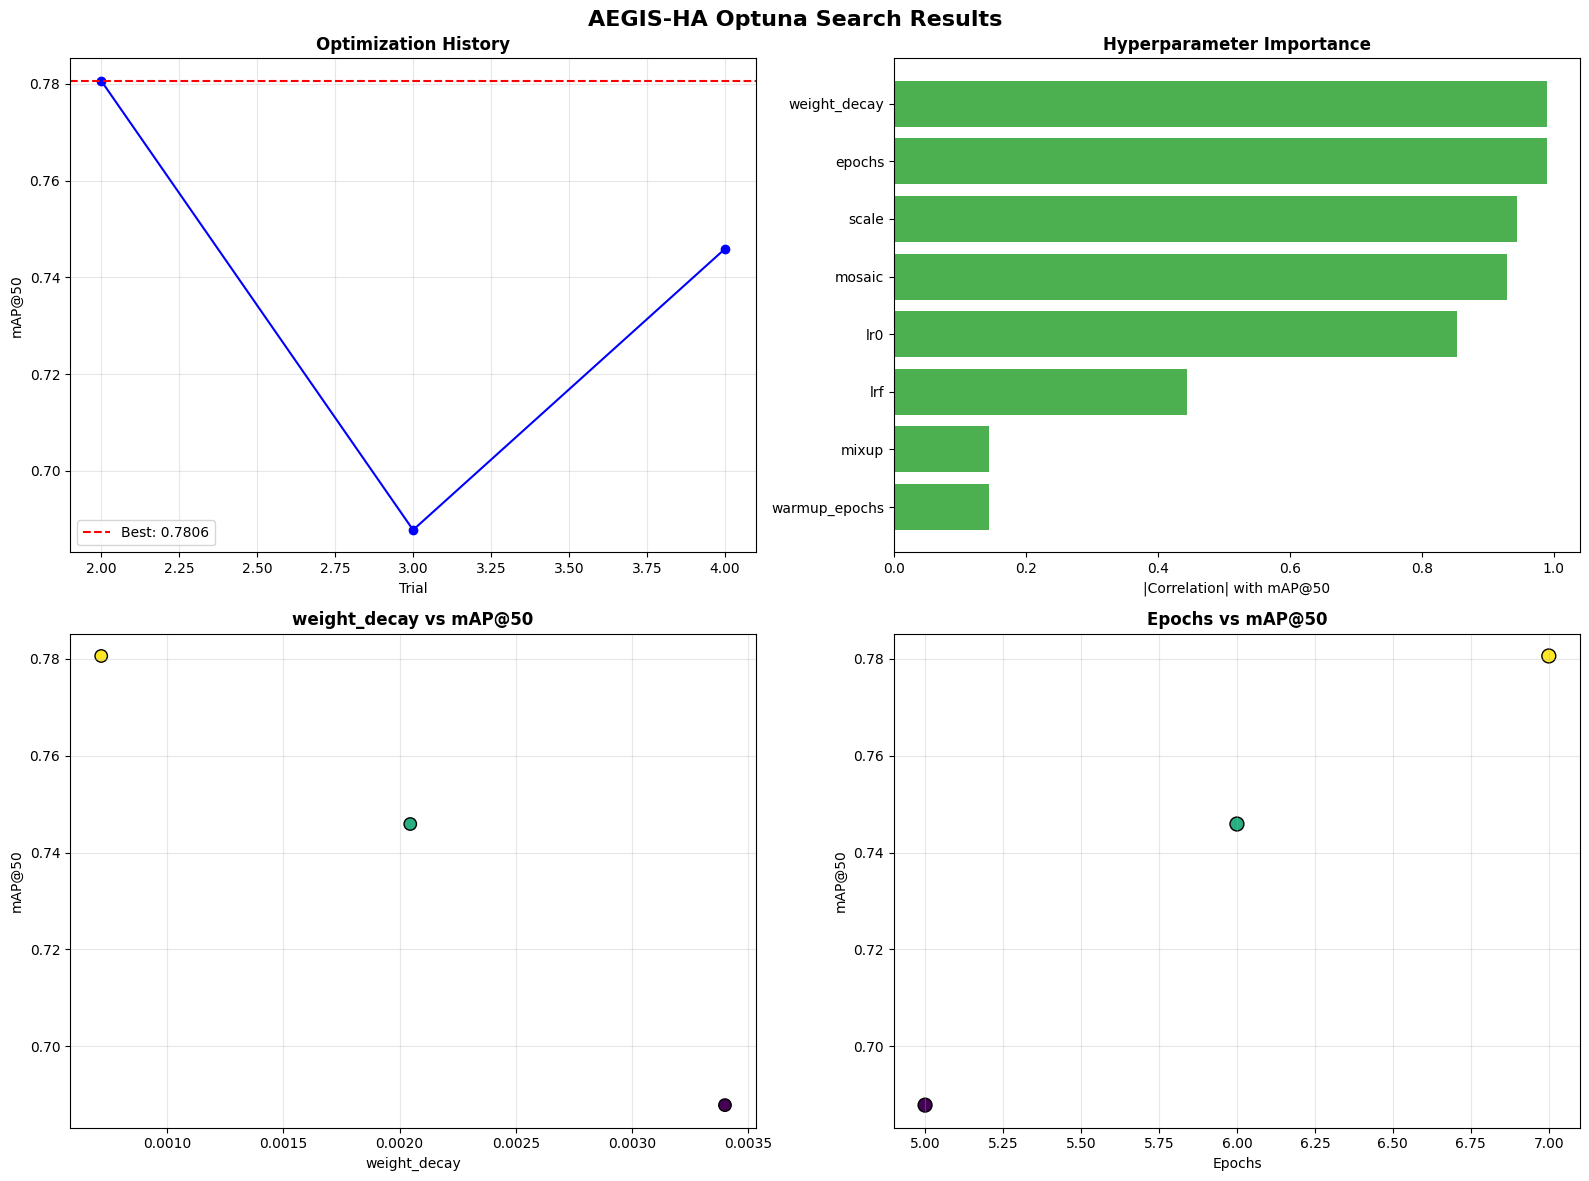


📊 Top 5 trials:
 trial    mAP50      lr0      lrf  epochs  warmup_epochs  weight_decay  mosaic  mixup  scale  map50_95  precision   recall  train_time_min
     2 0.780619 0.000118 0.048029       7              2      0.000716     0.5   0.00    0.6  0.349817   0.784737 0.773948       44.083738
     4 0.745895 0.000101 0.030990       6              1      0.002046     0.5   0.05    0.4  0.346758   0.797885 0.720529       38.420572
     3 0.687811 0.000200 0.038323       5              2      0.003399     0.6   0.00    0.3  0.287624   0.724086 0.685516       19.540375

✅ Saved to /content/drive/MyDrive/AEGIS_HA_Results


In [17]:
# ============================================================
# CELL 8: OPTUNA VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Build trial dataframe
trial_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        row = {'trial': t.number, 'mAP50': t.value}
        row.update(t.params)
        row.update(t.user_attrs)
        trial_data.append(row)

df = pd.DataFrame(trial_data).sort_values('trial')

# Check what columns actually exist
print("Available columns:", list(df.columns))

# Identify param columns (everything except trial, mAP50, and user_attrs)
non_param = {'trial', 'mAP50', 'map50_95', 'precision', 'recall', 'train_time_min'}
param_cols = [c for c in df.columns if c not in non_param]
print("Param columns:", param_cols)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Optimization history
axes[0,0].plot(df['trial'], df['mAP50'], 'bo-', markersize=6)
axes[0,0].axhline(y=df['mAP50'].max(), color='r', linestyle='--', label=f"Best: {df['mAP50'].max():.4f}")
axes[0,0].set_xlabel('Trial')
axes[0,0].set_ylabel('mAP@50')
axes[0,0].set_title('Optimization History', fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Parameter importance (correlation with mAP50)
numeric_params = df[param_cols].select_dtypes(include=[np.number]).columns.tolist()
if numeric_params:
    importances = df[numeric_params].corrwith(df['mAP50']).abs().sort_values(ascending=True)
    axes[0,1].barh(importances.index, importances.values, color='#4CAF50')
    axes[0,1].set_xlabel('|Correlation| with mAP@50')
    axes[0,1].set_title('Hyperparameter Importance', fontweight='bold')

# 3. Best param scatter (use first numeric param as x-axis)
if len(numeric_params) >= 1:
    best_param = importances.index[-1]  # Most important param
    axes[1,0].scatter(df[best_param], df['mAP50'], c=df['mAP50'], cmap='viridis', s=80, edgecolors='black')
    if df[best_param].min() > 0 and df[best_param].max() / df[best_param].min() > 100:
        axes[1,0].set_xscale('log')
    axes[1,0].set_xlabel(best_param)
    axes[1,0].set_ylabel('mAP@50')
    axes[1,0].set_title(f'{best_param} vs mAP@50', fontweight='bold')
    axes[1,0].grid(True, alpha=0.3)

# 4. Epochs vs mAP@50
if 'epochs' in df.columns:
    axes[1,1].scatter(df['epochs'], df['mAP50'], c=df['mAP50'], cmap='viridis', s=100, edgecolors='black')
    axes[1,1].set_xlabel('Epochs')
    axes[1,1].set_ylabel('mAP@50')
    axes[1,1].set_title('Epochs vs mAP@50', fontweight='bold')
    axes[1,1].grid(True, alpha=0.3)
elif len(numeric_params) >= 2:
    second_param = importances.index[-2]
    axes[1,1].scatter(df[second_param], df['mAP50'], c=df['mAP50'], cmap='viridis', s=100, edgecolors='black')
    axes[1,1].set_xlabel(second_param)
    axes[1,1].set_ylabel('mAP@50')
    axes[1,1].set_title(f'{second_param} vs mAP@50', fontweight='bold')
    axes[1,1].grid(True, alpha=0.3)

plt.suptitle('AEGIS-HA Optuna Search Results', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/optuna_results.png', dpi=200, bbox_inches='tight')
plt.show()

# Save CSV
df_sorted = df.sort_values('mAP50', ascending=False)
df_sorted.to_csv('/content/optuna_all_trials.csv', index=False)

print("\n📊 Top 5 trials:")
print(df_sorted.head().to_string(index=False))

# Backup to Drive
import shutil
for f in ['optuna_results.png', 'optuna_all_trials.csv']:
    shutil.copy2(f'/content/{f}', os.path.join(DRIVE_SAVE, f))
print(f"\n✅ Saved to {DRIVE_SAVE}")

In [20]:
# ============================================================
# CELL 9: USE BEST OPTUNA TRIAL WEIGHTS DIRECTLY
# ============================================================
from ultralytics import RTDETR
import os

# Find best trial's weights
best_trial_num = study.best_trial.number
best_weights = f'/content/optuna_runs/trial_{best_trial_num}/weights/best.pt'

if os.path.exists(best_weights):
    print(f" Best trial: #{best_trial_num}")
    print(f"   mAP@50: {study.best_value:.4f}")
    print(f"   Weights: {best_weights}")

    best_model = RTDETR(best_weights)

    # Quick validation to confirm
    val_r = best_model.val(data=yaml_path, split='val', imgsz=640, batch=8, device=0)
    print(f"\n   Confirmed mAP@50:    {val_r.box.map50:.4f}")
    print(f"   Confirmed mAP@50-95: {val_r.box.map:.4f}")
    print(f"   Precision:           {val_r.box.mp:.4f}")
    print(f"   Recall:              {val_r.box.mr:.4f}")

    # Copy to a clean location
    import shutil
    os.makedirs('/content/aegis_final/rtdetr_best/weights', exist_ok=True)
    shutil.copy2(best_weights, '/content/aegis_final/rtdetr_best/weights/best.pt')
    shutil.copy2(best_weights, os.path.join(DRIVE_SAVE, 'best.pt'))

    print(f"\n Weights saved to Drive. Move to Cell 10.")
else:
    print(f" Weights not found at {best_weights}")
    print("   Listing available trials:")
    for d in sorted(os.listdir('/content/optuna_runs')):
        w = f'/content/optuna_runs/{d}/weights/best.pt'
        print(f"   {d}: {'' if os.path.exists(w) else ''}")

 Best trial: #2
   mAP@50: 0.7806
   Weights: /content/optuna_runs/trial_2/weights/best.pt
Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary (fused): 315 layers, 31,987,850 parameters, 0 gradients, 105.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1023.9±593.6 MB/s, size: 30.3 KB)
val: Scanning /content/dataset/valid/labels.cache... 1396 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1396/1396 366.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 2186, len(boxes) = 2560. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 175/175 2.8it/s 1:03
                   all       1396       2560      0.785      0.774      0.781       0.35
                 drone   

In [21]:
# ============================================================
# CELL 10: VALIDATE
# ============================================================
from ultralytics import RTDETR

best_model = RTDETR('/content/aegis_final/rtdetr_best/weights/best.pt')

print(f"{'='*60}")
print(f"  VALIDATION SET METRICS")
print(f"{'='*60}")
val_r = best_model.val(data=yaml_path, split='val', imgsz=640, batch=8, device=0)
print(f"\n  mAP@50:      {val_r.box.map50:.4f}")
print(f"  mAP@50-95:   {val_r.box.map:.4f}")
print(f"  Precision:   {val_r.box.mp:.4f}")
print(f"  Recall:      {val_r.box.mr:.4f}")

print(f"\n{'='*60}")
print(f"  TEST SET METRICS (held-out)")
print(f"{'='*60}")
test_r = best_model.val(data=yaml_path, split='test', imgsz=640, batch=8, device=0)
print(f"\n  mAP@50:      {test_r.box.map50:.4f}")
print(f"  mAP@50-95:   {test_r.box.map:.4f}")
print(f"  Precision:   {test_r.box.mp:.4f}")
print(f"  Recall:      {test_r.box.mr:.4f}")

  VALIDATION SET METRICS
Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary (fused): 315 layers, 31,987,850 parameters, 0 gradients, 105.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 950.2±348.9 MB/s, size: 20.9 KB)
val: Scanning /content/dataset/valid/labels.cache... 1396 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1396/1396 418.2Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 2186, len(boxes) = 2560. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 175/175 2.8it/s 1:03
                   all       1396       2560      0.785      0.774      0.781       0.35
                 drone       1138       1308      0.869      0.911      0.912      0.459
   

CSV columns found: ['epoch', 'time', 'train/giou_loss', 'train/cls_loss', 'train/l1_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/giou_loss', 'val/cls_loss', 'val/l1_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
Epochs logged: 7

0: 640x640 2 drones, 40.8ms
1: 640x640 1 drone, 40.8ms
2: 640x640 1 drone, 40.8ms
3: 640x640 2 birds, 40.8ms
4: 640x640 1 drone, 40.8ms
5: 640x640 1 drone, 40.8ms
6: 640x640 1 drone, 40.8ms
7: 640x640 1 drone, 40.8ms
8: 640x640 4 birds, 40.8ms
9: 640x640 1 drone, 40.8ms
10: 640x640 2 drones, 40.8ms
11: 640x640 2 birds, 40.8ms
Speed: 0.9ms preprocess, 40.8ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


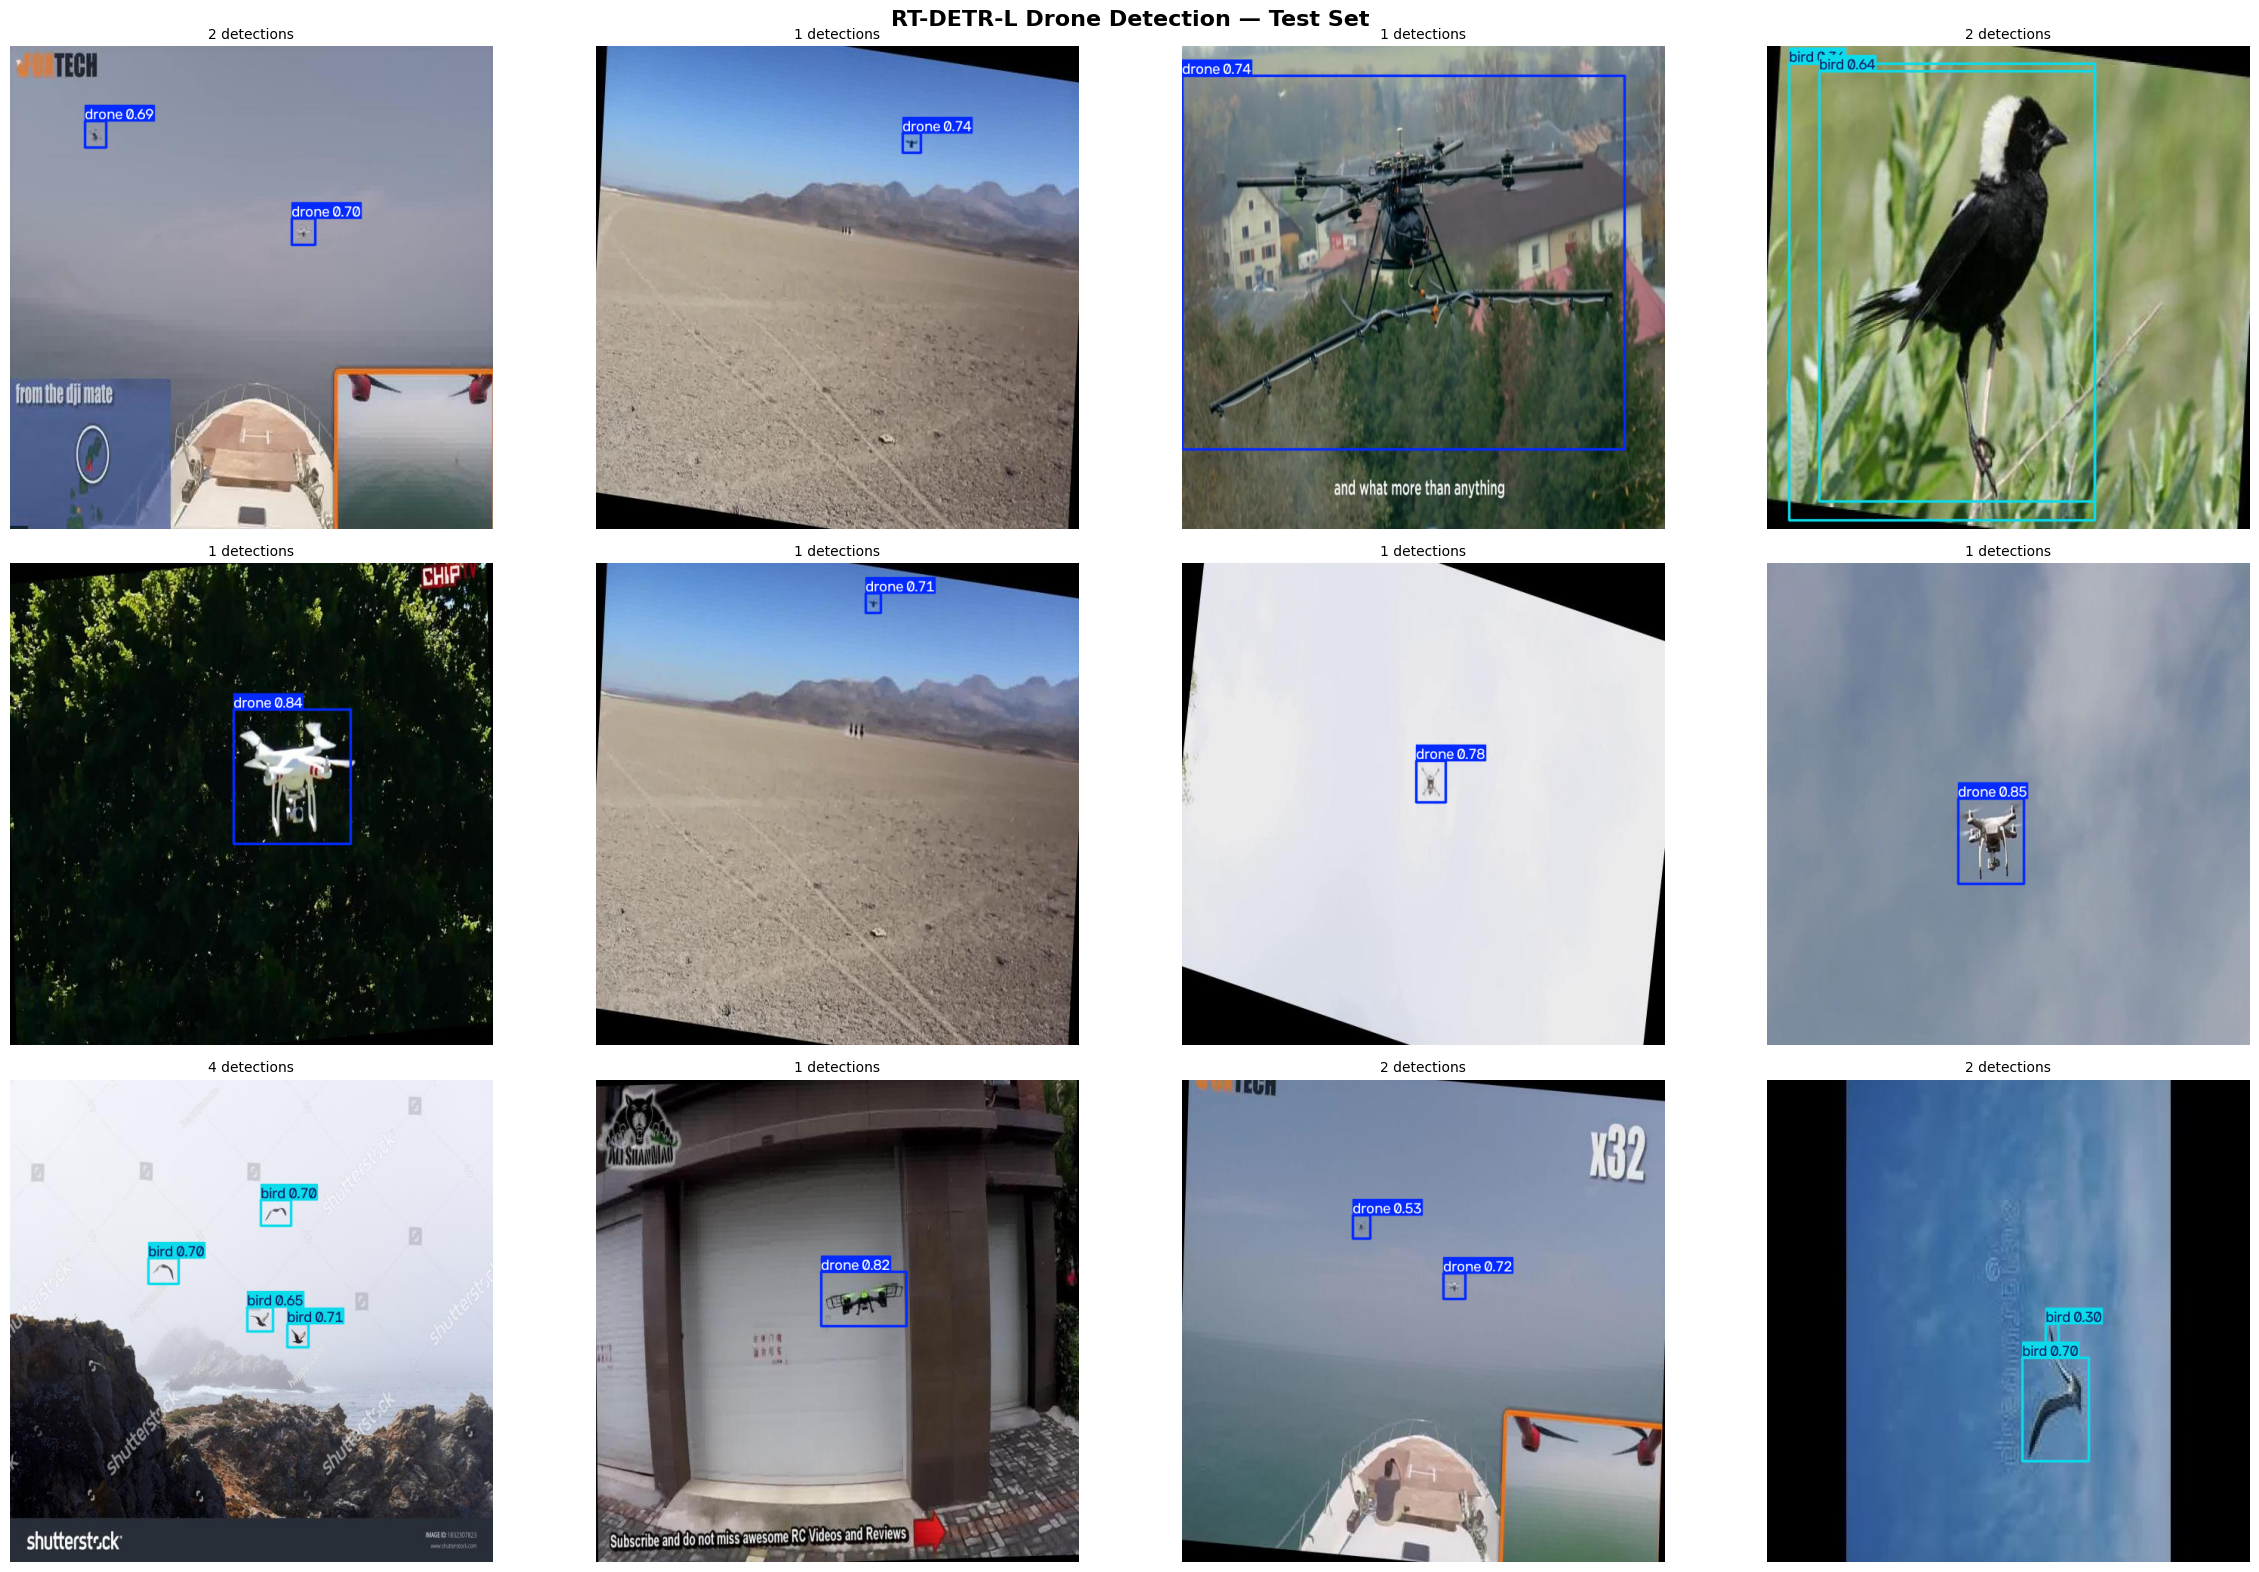


✅ Saved to /content/drive/MyDrive/AEGIS_HA_Results


In [23]:
# ============================================================
# CELL 11: INFERENCE VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
import cv2, random, os

# ── Check what the CSV actually contains ──
best_trial_num = study.best_trial.number
csv_path = f'/content/optuna_runs/trial_{best_trial_num}/results.csv'

if os.path.exists(csv_path):
    import pandas as pd
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    print("CSV columns found:", list(df.columns))
    print(f"Epochs logged: {len(df)}")

# ── Test inference grid ──
test_img_dir = os.path.join(DATASET_ROOT, 'test', 'images')
test_images = [f for f in os.listdir(test_img_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
samples = random.sample(test_images, min(12, len(test_images)))
sample_paths = [os.path.join(test_img_dir, f) for f in samples]

results = best_model.predict(source=sample_paths, imgsz=640, conf=0.3, device=0, save=False)

fig, axes = plt.subplots(3, 4, figsize=(24, 16))
for ax, result in zip(axes.flat, results):
    img_rgb = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(f'{len(result.boxes)} detections', fontsize=10)
    ax.axis('off')

plt.suptitle('RT-DETR-L Drone Detection — Test Set', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/test_inference_grid.png', dpi=200, bbox_inches='tight')
plt.show()

# Backup to Drive
import shutil
shutil.copy2('/content/test_inference_grid.png', DRIVE_SAVE)
print(f"\n Saved to {DRIVE_SAVE}")

In [24]:
# ============================================================
# CELL 12: SPEED BENCHMARK + SAVE TO DRIVE
# ============================================================
import time
import numpy as np
import shutil
import os

# ── Speed benchmark ──
test_img_dir = os.path.join(DATASET_ROOT, 'test', 'images')
test_images = [f for f in os.listdir(test_img_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]

dummy = np.random.randint(0, 255, (640, 640, 3), dtype=np.uint8)
for _ in range(5):
    best_model.predict(dummy, imgsz=640, device=0, verbose=False)

test_imgs = [os.path.join(test_img_dir, f) for f in test_images[:50]]
latencies = []
for img_path in test_imgs:
    t0 = time.time()
    best_model.predict(img_path, imgsz=640, device=0, verbose=False)
    latencies.append((time.time() - t0) * 1000)

latencies = np.array(latencies)
fps = 1000 / latencies.mean()

print(f"{'='*50}")
print(f"  INFERENCE SPEED (RT-DETR-L @ 640px, T4)")
print(f"{'='*50}")
print(f"  Mean latency:   {latencies.mean():.1f} ms")
print(f"  Median:         {np.median(latencies):.1f} ms")
print(f"  P95:            {np.percentile(latencies, 95):.1f} ms")
print(f"  FPS:            {fps:.1f}")
print(f"\n  For PPT: 'RT-DETR-L achieves {fps:.0f} FPS on T4,")
print(f"  projected ~15-20 FPS on Jetson Orin Nano'")

# ── Save everything to Drive ──
src = '/content/aegis_final/rtdetr_best'
dst = os.path.join(DRIVE_SAVE, 'rtdetr_final_optimized')
if os.path.exists(dst):
    shutil.rmtree(dst)
if os.path.exists(src):
    shutil.copytree(src, dst)

# Copy all result files
for f in ['/content/optuna_results.png', '/content/optuna_all_trials.csv',
          '/content/test_inference_grid.png', '/content/dataset_overview.png']:
    if os.path.exists(f):
        shutil.copy2(f, DRIVE_SAVE)

print(f"\n{'='*50}")
print(f"  ALL RESULTS SAVED TO: {DRIVE_SAVE}/")
print(f"{'='*50}")

  INFERENCE SPEED (RT-DETR-L @ 640px, T4)
  Mean latency:   58.5 ms
  Median:         56.7 ms
  P95:            72.9 ms
  FPS:            17.1

  For PPT: 'RT-DETR-L achieves 17 FPS on T4,
  projected ~15-20 FPS on Jetson Orin Nano'

  ALL RESULTS SAVED TO: /content/drive/MyDrive/AEGIS_HA_Results/
